# Trening Faster R-CNN ResNet50-FPN v2 - SoccerNet (v4)

Faster R-CNN do detekcji ball / player / referee. Cel v4: **wycisnac maksa z kazdej klasy**
przy **optymalnie szybkim** treningu (pelne wykorzystanie A100).

Co bierzemy z v3 (bo zadzialalo dla wszystkich klas):
- Natywna rozdzielczosc 1080/1920
- Drobniejsze kotwice (16,32,64,128,256)
- Wiecej propozycji RPN

Co zmieniamy w v4:
- **Warm-start z v3 best.pt** — startujemy z gotowego, dobrego modelu (wagi), a optimizer/scheduler od zera
- **Pelne wygaszenie LR** — krotszy cosine (25 epok), ktory faktycznie zejdzie do LR_MIN
  (v3 zatrzymal sie z LR jeszcze wysokim -> AP@0.5:0.95 mialo zapas)
- **Wykorzystanie A100** — duzy batch (8) zamiast 2, TF32 + cudnn.benchmark, wiecej workerow
- **BALL_OVERSAMPLE=1** — oversampling nie balansowal klas (94% klatek ma pilke), tylko potrajal epoke
- **Zoom-crop z losowym srodkiem** (nie wokol pilki) — nie obcina zawodnikow na brzegach kadru
- Wybor best.pt po **mAP@0.5:0.95**; punkt startowy (warm-start) jest ewaluowany i zapisany jako baza,
  wiec v4 nie moze wyjsc gorzej niz v3

## 1. Konfiguracja srodowiska

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil, glob, time, random
import torch
import torchvision
import numpy as np

# ---- Optymalizacje pod A100 (Ampere) ----
torch.backends.cudnn.benchmark = True          # autotuning konwolucji (staly rozmiar wejscia 1920x1080)
torch.backends.cuda.matmul.allow_tf32 = True   # TF32 na matmul (szybciej, A100)
torch.backends.cudnn.allow_tf32 = True         # TF32 na cudnn

gpu_name = torch.cuda.get_device_name(0)
gpu_mem  = torch.cuda.get_device_properties(0).total_memory / (1024**3)
print(f"GPU: {gpu_name} ({gpu_mem:.1f} GB)")
print(f"PyTorch: {torch.__version__}, CUDA: {torch.version.cuda}")
print(f"Torchvision: {torchvision.__version__}")
print("TF32 + cudnn.benchmark: ON")

Mounted at /content/drive
GPU: NVIDIA A100-SXM4-40GB (39.5 GB)
PyTorch: 2.11.0+cu128, CUDA: 12.8
Torchvision: 0.26.0+cu128
TF32 + cudnn.benchmark: ON


## 2. Sciezki i hiperparametry

In [3]:
ZIP_PATH       = "/content/drive/MyDrive/CvFootballTracker_Data/Detection/yoloformat.zip"
LOCAL_DATA_DIR = "/content/yoloformat"
PROJECT_DIR    = "/content/drive/MyDrive/CvFootballTracker_Data/results"
RUN_NAME       = "frcnn_soccernet_v4"   # swiezy katalog

# ---- Warm-start: wczytaj WAGI z v3 best.pt (optimizer/scheduler i tak budujemy od zera) ----
WARM_START_PATH = f"{PROJECT_DIR}/frcnn_soccernet_v3/best.pt"   # ustaw "" aby startowac od COCO

# ---- Architektura (zostaje z v3 — pomoglo wszystkim klasom) ----
NUM_CLASSES  = 4
IMG_MIN_SIZE = 1080
IMG_MAX_SIZE = 1920
ANCHOR_SIZES  = ((16,), (32,), (64,), (128,), (256,))
ANCHOR_RATIOS = (0.5, 1.0, 2.0)

# ---- Trening (pod A100: duzy batch zamiast batch=2) ----
BATCH_SIZE   = 8       # bylo 2 -> batch 2 marnowal 80 GB. Jak OOM przy 1920: zejdz na 4 i ACCUM=8
ACCUM_STEPS  = 4       # efektywny batch = 8*4 = 32 (bez zmian -> LR bez przeliczania)
NUM_EPOCHS   = 25      # krotszy, ale PELNY cosine (v3 nie zdazyl wygasic LR)
PATIENCE     = 8

# ---- Oversampling / augmentacja ----
BALL_OVERSAMPLE = 1    # wylaczony (nie balansowal klas, tylko potrajal epoke)
ZOOM_AUG_PROB   = 0.3  # zoom-in crop z LOSOWYM srodkiem (scale jitter, nie obcina graczy celowo)

# ---- Optimizer ----
LR           = 0.003   # nizszy peak niz v3 (0.005) — to fine-tune warm-startu, nie trening od zera
MOMENTUM     = 0.9
WEIGHT_DECAY = 0.0005
BACKBONE_LR_FACTOR = 0.1

# ---- Scheduler ----
WARMUP_EPOCHS = 1
LR_MIN        = 1e-6

# ---- Ewaluacja mAP w trakcie treningu ----
MAP_EVAL_SAMPLES = 800

# ---- Inne ----
NUM_WORKERS = 8        # bylo 4 — przy szybkim GPU dataloading jest waskim gardlem
SEED        = 17
USE_AMP     = True

CLASS_NAMES = {0: 'background', 1: 'ball', 2: 'player', 3: 'referee'}

print(f"Efektywny batch size: {BATCH_SIZE * ACCUM_STEPS}")
print(f"Obraz: min_size={IMG_MIN_SIZE}, max_size={IMG_MAX_SIZE}")
print(f"Kotwice: {ANCHOR_SIZES}")
print(f"Warm-start: {WARM_START_PATH if WARM_START_PATH else '(brak — start od COCO)'}")
print(f"Epoki: {NUM_EPOCHS} | LR peak: {LR} | workers: {NUM_WORKERS}")

Efektywny batch size: 32
Obraz: min_size=1080, max_size=1920
Kotwice: ((16,), (32,), (64,), (128,), (256,))
Warm-start: /content/drive/MyDrive/CvFootballTracker_Data/results/frcnn_soccernet_v3/best.pt
Epoki: 25 | LR peak: 0.003 | workers: 8


## 3. Ekstrakcja danych z Google Drive

In [4]:
if not os.path.exists(LOCAL_DATA_DIR):
    print("Rozpakowywanie archiwum...")
    shutil.unpack_archive(ZIP_PATH, extract_dir="/content/")
    print("Zakonczono.")
else:
    print("Dane juz dostepne na dysku lokalnym.")

n_train = len(glob.glob(f"{LOCAL_DATA_DIR}/train/*/images/*.jpg"))
n_valid = len(glob.glob(f"{LOCAL_DATA_DIR}/valid/*/images/*.jpg"))
print(f"Liczba obrazow - train: {n_train}, valid: {n_valid}")

Rozpakowywanie archiwum...
Zakonczono.
Liczba obrazow - train: 11500, valid: 8250


## 4. Dataset i DataLoader

- Obrazy ladowane w **oryginalnej rozdzielczosci** (brak resize do kwadratu!)
- Boxy konwertowane z YOLO norm (cx cy w h) na piksele (x1 y1 x2 y2)
- Augmentacja treningowa: **RandomHorizontalFlip** + **ColorJitter**
- FPN sam zajmie sie skalowaniem i paddingiem wewnetrznie

In [5]:
import cv2
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms.functional as TF


def _label_has_ball(lbl_path):
    if not lbl_path.exists():
        return False
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if parts and parts[0] == "0":
                return True
    return False


class YOLOFormatDataset(Dataset):
    """YOLO-format -> torchvision Faster R-CNN. Oryginalna rozdzielczosc (FPN skaluje).
    Augmentacja: zoom-in crop (losowy srodek, zachowuje 16:9) + flip + ColorJitter."""

    def __init__(self, base_dir, augment=False, ball_oversample=1, zoom_prob=0.0):
        self.augment = augment
        self.zoom_prob = zoom_prob
        self.samples = []

        base = Path(base_dir)
        n_base, n_ball = 0, 0
        for clip_dir in sorted(base.iterdir()):
            images_dir = clip_dir / "images"
            labels_dir = clip_dir / "labels"
            if not images_dir.is_dir():
                continue
            for img_path in sorted(images_dir.glob("*.jpg")):
                lbl_path = labels_dir / img_path.with_suffix(".txt").name
                self.samples.append((img_path, lbl_path))
                n_base += 1
                if ball_oversample > 1 and _label_has_ball(lbl_path):
                    n_ball += 1
                    for _ in range(ball_oversample - 1):
                        self.samples.append((img_path, lbl_path))

        extra = len(self.samples) - n_base
        print(f"  Dataset: {n_base} klatek bazowych z {base_dir} (augment={augment})")
        if extra:
            print(f"           +{extra} powtorzen klatek z pilka ({n_ball} unikalnych) "
                  f"-> {len(self.samples)} probek")

    def __len__(self):
        return len(self.samples)

    def _zoom_crop(self, image, boxes_t, labels_t):
        """Zoom-in crop ze scale jitter. Srodek LOSOWY (nie wokol pilki), zachowuje 16:9
        -> po normalizacji FPN wejscie dalej 1920x1080 (cudnn.benchmark stabilny).
        Boxy przyciete; zawodnik przy brzegu moze wypasc (filtr 30% pola)."""
        h, w = image.shape[:2]
        if len(boxes_t) == 0:
            return image, boxes_t, labels_t
        scale = random.uniform(1.1, 1.5)
        cw, ch = int(w / scale), int(h / scale)
        if cw < 64 or ch < 64:
            return image, boxes_t, labels_t
        x0 = random.randint(0, w - cw)
        y0 = random.randint(0, h - ch)
        crop = np.ascontiguousarray(image[y0:y0 + ch, x0:x0 + cw])

        b = boxes_t.clone()
        b[:, [0, 2]] -= x0
        b[:, [1, 3]] -= y0
        orig_area = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
        b[:, [0, 2]] = b[:, [0, 2]].clamp(0, cw)
        b[:, [1, 3]] = b[:, [1, 3]].clamp(0, ch)
        nw = b[:, 2] - b[:, 0]; nh = b[:, 3] - b[:, 1]
        keep = (nw > 2) & (nh > 2) & ((nw * nh) > 0.3 * orig_area)
        if keep.sum() == 0:
            return image, boxes_t, labels_t
        return crop, b[keep], labels_t[keep]

    def __getitem__(self, idx):
        img_path, lbl_path = self.samples[idx]

        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h_orig, w_orig = image.shape[:2]

        boxes, labels = [], []
        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls_yolo = int(parts[0])  # 0=ball, 1=player, 2=referee
                    cx, cy, bw, bh = map(float, parts[1:5])
                    x1 = max(0.0, (cx - bw / 2) * w_orig)
                    y1 = max(0.0, (cy - bh / 2) * h_orig)
                    x2 = min(float(w_orig), (cx + bw / 2) * w_orig)
                    y2 = min(float(h_orig), (cy + bh / 2) * h_orig)
                    if x2 > x1 + 1 and y2 > y1 + 1:
                        boxes.append([x1, y1, x2, y2])
                        labels.append(cls_yolo + 1)  # +1 bo 0=background

        if boxes:
            boxes_t = torch.tensor(boxes, dtype=torch.float32)
            labels_t = torch.tensor(labels, dtype=torch.int64)
        else:
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros(0, dtype=torch.int64)

        if self.augment:
            # 0. Zoom-in crop (scale jitter, losowy srodek)
            if random.random() < self.zoom_prob and len(boxes_t) > 0:
                image, boxes_t, labels_t = self._zoom_crop(image, boxes_t, labels_t)
            h_cur, w_cur = image.shape[:2]

            # 1. Random Horizontal Flip
            if random.random() < 0.5:
                image = image[:, ::-1, :].copy()
                if len(boxes_t) > 0:
                    boxes_t[:, [0, 2]] = w_cur - boxes_t[:, [2, 0]]

            # 2. ColorJitter
            image_pil = TF.to_pil_image(np.ascontiguousarray(image))
            image_pil = torchvision.transforms.ColorJitter(
                brightness=0.3, contrast=0.3, saturation=0.3, hue=0.02
            )(image_pil)
            image = np.array(image_pil)

        image_t = TF.to_tensor(image)
        return image_t, {"boxes": boxes_t, "labels": labels_t}


def collate_fn(batch):
    return tuple(zip(*batch))


torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)

print("Ladowanie danych...")
train_dataset = YOLOFormatDataset(
    f"{LOCAL_DATA_DIR}/train", augment=True,
    ball_oversample=BALL_OVERSAMPLE, zoom_prob=ZOOM_AUG_PROB,
)
valid_dataset = YOLOFormatDataset(f"{LOCAL_DATA_DIR}/valid", augment=False)

_dl_kw = dict(num_workers=NUM_WORKERS, pin_memory=True,
              persistent_workers=(NUM_WORKERS > 0), prefetch_factor=4 if NUM_WORKERS > 0 else None)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_fn, drop_last=True, **_dl_kw,
)
valid_loader = DataLoader(
    valid_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_fn, **_dl_kw,
)

# Podzbior valid do szybkiego mAP co epoke
_n_map = min(MAP_EVAL_SAMPLES, len(valid_dataset))
_rng = np.random.RandomState(SEED)
_map_idx = _rng.choice(len(valid_dataset), size=_n_map, replace=False).tolist()
map_eval_loader = DataLoader(
    Subset(valid_dataset, _map_idx), batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_fn, **_dl_kw,
)

print(f"Batchy: train={len(train_loader)}, valid={len(valid_loader)}")
print(f"mAP-eval subset: {_n_map} klatek")
print(f"Iteracji/epoka: {len(train_loader)}, aktualizacji wag/epoka: {len(train_loader)//ACCUM_STEPS}")

Ladowanie danych...
  Dataset: 11500 klatek bazowych z /content/yoloformat/train (augment=True)
  Dataset: 8250 klatek bazowych z /content/yoloformat/valid (augment=False)
Batchy: train=1437, valid=1032
mAP-eval subset: 800 klatek
Iteracji/epoka: 1437, aktualizacji wag/epoka: 359


## 5. Inicjalizacja modelu

- Faster R-CNN ResNet50-FPN v2 z COCO pretrained
- Nowa glowica (4 klasy)
- **min_size/max_size** ustawione zamiast recznego resize
- SGD + **LinearLR warmup** (1 epoka) + **CosineAnnealingLR**
- Resume z checkpointu na Drive

In [6]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator

save_dir = f"{PROJECT_DIR}/{RUN_NAME}"
os.makedirs(save_dir, exist_ok=True)
best_path = f"{save_dir}/best.pt"
last_path = f"{save_dir}/last.pt"


def create_model(num_classes, min_size=IMG_MIN_SIZE, max_size=IMG_MAX_SIZE):
    model = fasterrcnn_resnet50_fpn_v2(
        weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT,
        min_size=min_size,
        max_size=max_size,
        rpn_pre_nms_top_n_train=3000, rpn_post_nms_top_n_train=2000,
        rpn_pre_nms_top_n_test=2000,  rpn_post_nms_top_n_test=1000,
    )
    aspect_ratios = (ANCHOR_RATIOS,) * len(ANCHOR_SIZES)
    model.rpn.anchor_generator = AnchorGenerator(ANCHOR_SIZES, aspect_ratios)

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


device = torch.device("cuda")
model = create_model(NUM_CLASSES)
model.to(device)

# ---- Optimizer (rozne LR) ----
backbone_params = [p for n, p in model.named_parameters() if "backbone" in n and p.requires_grad]
head_params     = [p for n, p in model.named_parameters() if "backbone" not in n and p.requires_grad]
optimizer = torch.optim.SGD([
    {"params": backbone_params, "lr": LR * BACKBONE_LR_FACTOR},
    {"params": head_params,     "lr": LR},
], momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
print(f"LR backbone: {LR * BACKBONE_LR_FACTOR:.5f}, LR glowica: {LR:.5f}")

# ---- Scheduler: warmup + PELNY cosine na NUM_EPOCHS ----
steps_per_epoch = len(train_loader) // ACCUM_STEPS
warmup_steps = steps_per_epoch * WARMUP_EPOCHS
cosine_steps = steps_per_epoch * (NUM_EPOCHS - WARMUP_EPOCHS)
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, total_iters=warmup_steps)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cosine_steps, eta_min=LR_MIN)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[warmup_steps]
)

scaler = torch.amp.GradScaler(enabled=USE_AMP)

start_epoch = 0
best_map = -1.0
global_step = 0

# ---- Logika startu: resume v4 > warm-start z v3 > COCO ----
if os.path.exists(last_path):
    # Wznowienie przerwanego treningu v4 (pelny stan)
    ckpt = torch.load(last_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    scaler.load_state_dict(ckpt["scaler_state_dict"])
    start_epoch = ckpt["epoch"] + 1
    best_map = ckpt.get("best_map", -1.0)
    global_step = ckpt.get("global_step", 0)
    print(f"Wznowienie v4 z epoki {start_epoch} (best_map={best_map:.4f}, step={global_step})")
elif WARM_START_PATH and os.path.exists(WARM_START_PATH):
    # Warm-start: tylko WAGI z v3 (kompatybilne — ta sama architektura/kotwice).
    ck = torch.load(WARM_START_PATH, map_location=device, weights_only=False)
    model.load_state_dict(ck["model_state_dict"])
    print(f"Warm-start z {WARM_START_PATH}")
    print(f"  (v3 epoch {ck.get('epoch', '?')}, mAP50-95={ck.get('map5095', ck.get('best_map', float('nan'))):.4f})")
    print("  Wagi przeniesione; optimizer i scheduler budowane od zera (swiezy cosine).")
else:
    print("Start od wag COCO pretrained (brak warm-start).")

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model na: {device} | parametry trenowalne: {n_params/1e6:.1f}M")
print(f"Kotwice: {ANCHOR_SIZES}")
print(f"Scheduler: warmup {WARMUP_EPOCHS} epok (LR {LR*0.1:.4f} -> {LR}) + cosine -> {LR_MIN}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 242MB/s]


LR backbone: 0.00030, LR glowica: 0.00300
Warm-start z /content/drive/MyDrive/CvFootballTracker_Data/results/frcnn_soccernet_v3/best.pt
  (v3 epoch 9, mAP50-95=0.4708)
  Wagi przeniesione; optimizer i scheduler budowane od zera (swiezy cosine).
Model na: cuda | parametry trenowalne: 43.0M
Kotwice: ((16,), (32,), (64,), (128,), (256,))
Scheduler: warmup 1 epok (LR 0.0003 -> 0.003) + cosine -> 1e-06


## 6. Trening

- **Gradient accumulation** (efektywny batch 32)
- **Mixed precision** (AMP) — szybciej, mniej VRAM
- **Gradient clipping** (stabilnosc)
- Co epoke: szybki **mAP na podzbiorze valid**, zapis best.pt po **mAP@0.5:0.95**, early stopping

In [7]:
from torchvision.ops import box_iou


def train_one_epoch(model, dataloader, optimizer, scheduler, scaler, device, epoch, accum_steps):
    model.train()
    total_loss = 0.0
    n_batches = 0
    global global_step
    optimizer.zero_grad()

    for batch_idx, (images, targets) in enumerate(dataloader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        valid_pairs = [(img, tgt) for img, tgt in zip(images, targets) if tgt["boxes"].shape[0] > 0]
        if not valid_pairs:
            continue
        images, targets = zip(*valid_pairs)
        images, targets = list(images), list(targets)

        with torch.amp.autocast(device_type="cuda", enabled=USE_AMP):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values()) / accum_steps

        scaler.scale(losses).backward()

        if (batch_idx + 1) % accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()
            global_step += 1

        total_loss += losses.item() * accum_steps
        n_batches += 1

        if (batch_idx + 1) % 400 == 0:
            lr_now = optimizer.param_groups[0]["lr"]
            print(f"  Epoch {epoch} | Batch {batch_idx+1}/{len(dataloader)} | "
                  f"Loss: {losses.item()*accum_steps:.4f} | LR: {lr_now:.6f}")

    return total_loss / max(n_batches, 1)


# ---------- Szybki mAP (COCO-style) do wyboru checkpointu ----------
def _compute_ap(recalls, precisions):
    mrec = np.concatenate(([0.0], recalls, [1.0]))
    mpre = np.concatenate(([1.0], precisions, [0.0]))
    for i in range(len(mpre) - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])
    rp = np.linspace(0, 1, 101)
    pr = np.zeros(101)
    for i, r in enumerate(rp):
        idx = np.where(mrec >= r)[0]
        if len(idx) > 0:
            pr[i] = mpre[idx[0]]
    return pr.mean()


def _ap_class(all_preds, all_gts, class_id, iou_thr):
    preds = []
    n_gt = 0
    gt_matched = {}
    for img_idx, (pred, gt) in enumerate(zip(all_preds, all_gts)):
        gm = gt["labels"].numpy() == class_id
        n_gt += int(gm.sum())
        gt_matched[img_idx] = np.zeros(int(gm.sum()), dtype=bool)
        pm = pred["labels"].numpy() == class_id
        pb = pred["boxes"].numpy()[pm]
        ps = pred["scores"].numpy()[pm]
        for j in range(len(pb)):
            preds.append((img_idx, ps[j], pb[j]))
    if n_gt == 0:
        return None
    preds.sort(key=lambda x: x[1], reverse=True)
    tp = np.zeros(len(preds)); fp = np.zeros(len(preds))
    for i, (img_idx, score, pred_box) in enumerate(preds):
        gt = all_gts[img_idx]
        gm = gt["labels"].numpy() == class_id
        gb = gt["boxes"].numpy()[gm]
        if len(gb) == 0:
            fp[i] = 1; continue
        ious = box_iou(torch.from_numpy(pred_box).unsqueeze(0).float(),
                       torch.from_numpy(gb).float()).numpy()[0]
        k = ious.argmax()
        if ious[k] >= iou_thr and not gt_matched[img_idx][k]:
            tp[i] = 1; gt_matched[img_idx][k] = True
        else:
            fp[i] = 1
    cum_tp = np.cumsum(tp); cum_fp = np.cumsum(fp)
    recalls = cum_tp / n_gt
    precisions = cum_tp / np.maximum(cum_tp + cum_fp, 1e-9)
    return _compute_ap(recalls, precisions)


@torch.no_grad()
def evaluate_map(model, dataloader, device):
    """Zwraca (mAP50, mAP50-95, dict per-klasa AP50)."""
    model.eval()
    all_preds, all_gts = [], []
    for images, targets in dataloader:
        images = [img.to(device) for img in images]
        with torch.amp.autocast(device_type="cuda", enabled=USE_AMP):
            preds = model(images)
        all_preds.extend([{k: v.cpu() for k, v in p.items()} for p in preds])
        all_gts.extend(targets)
    thrs = np.arange(0.5, 1.0, 0.05)
    cls_ap50, ap50_list, ap5095_list = {}, [], []
    for cid, cname in {1: "ball", 2: "player", 3: "referee"}.items():
        ap50 = _ap_class(all_preds, all_gts, cid, 0.5)
        if ap50 is None:
            continue
        aps = [_ap_class(all_preds, all_gts, cid, t) for t in thrs]
        aps = [a for a in aps if a is not None]
        cls_ap50[cname] = ap50
        ap50_list.append(ap50)
        ap5095_list.append(float(np.mean(aps)))
    return float(np.mean(ap50_list)), float(np.mean(ap5095_list)), cls_ap50


def save_checkpoint(model, optimizer, scheduler, scaler, epoch, best_map, global_step, path, extra=None):
    ckpt = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "epoch": epoch, "best_map": best_map, "global_step": global_step,
    }
    if extra:
        ckpt.update(extra)
    torch.save(ckpt, path)


# ---- Ewaluacja punktu startowego (warm-start): seed best_map, zapis jako baza ----
# Dzieki temu v4 best.pt nie moze wyjsc gorzej niz model, z ktorego startujemy.
if start_epoch == 0:
    s50, s5095, scls = evaluate_map(model, map_eval_loader, device)
    print(f"Punkt startowy: mAP50={s50:.4f} | mAP50-95={s5095:.4f} | ball AP50={scls.get('ball', float('nan')):.4f}")
    if s5095 > best_map:
        best_map = s5095
        save_checkpoint(model, optimizer, scheduler, scaler, -1, best_map, global_step, best_path,
                        extra={"map50": s50, "map5095": s5095, "ball_ap50": scls.get("ball", float("nan"))})
        print(f"  -> Zapisano punkt startowy jako best (mAP50-95={best_map:.4f})")

# ---- Petla treningowa ----
print(f"\nStart treningu: epoki {start_epoch+1}-{NUM_EPOCHS}")
print(f"Batch: {BATCH_SIZE} x {ACCUM_STEPS} accum = efektywny {BATCH_SIZE*ACCUM_STEPS}")
print(f"Wybor best.pt: mAP@0.5:0.95 na {len(map_eval_loader.dataset)} klatkach valid")
print(f"Wyniki: {save_dir}\n")

epochs_no_improve = 0
history = []

for epoch in range(start_epoch, NUM_EPOCHS):
    t0 = time.time()

    train_loss = train_one_epoch(
        model, train_loader, optimizer, scheduler, scaler, device, epoch + 1, ACCUM_STEPS
    )

    map50, map5095, cls_ap50 = evaluate_map(model, map_eval_loader, device)
    ball_ap = cls_ap50.get("ball", float("nan"))

    elapsed = time.time() - t0
    lr_now = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | train: {train_loss:.4f} | "
        f"mAP50: {map50:.4f} | mAP50-95: {map5095:.4f} | ball AP50: {ball_ap:.4f} | "
        f"lr: {lr_now:.6f} | {elapsed:.0f}s"
    )

    history.append({"epoch": epoch+1, "train_loss": train_loss, "map50": map50,
                    "map5095": map5095, "ball_ap50": ball_ap, "lr": lr_now})

    save_checkpoint(model, optimizer, scheduler, scaler, epoch, best_map, global_step, last_path)

    if map5095 > best_map:
        best_map = map5095
        epochs_no_improve = 0
        save_checkpoint(model, optimizer, scheduler, scaler, epoch, best_map, global_step, best_path,
                        extra={"map50": map50, "map5095": map5095, "ball_ap50": ball_ap})
        print(f"  -> Nowy best (mAP50-95={map5095:.4f}, ball AP50={ball_ap:.4f})")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping po {epoch+1} epokach (brak poprawy mAP przez {PATIENCE} epok)")
        break

print(f"\nTrening zakonczony. Best mAP50-95: {best_map:.4f}")
print(f"Checkpointy: {save_dir}")

Punkt startowy: mAP50=0.8390 | mAP50-95=0.4708 | ball AP50=0.6102
  -> Zapisano punkt startowy jako best (mAP50-95=0.4708)

Start treningu: epoki 1-25
Batch: 8 x 4 accum = efektywny 32
Wybor best.pt: mAP@0.5:0.95 na 800 klatkach valid
Wyniki: /content/drive/MyDrive/CvFootballTracker_Data/results/frcnn_soccernet_v4

  Epoch 1 | Batch 400/1437 | Loss: 0.3896 | LR: 0.000105
  Epoch 1 | Batch 800/1437 | Loss: 0.5310 | LR: 0.000180
  Epoch 1 | Batch 1200/1437 | Loss: 0.3371 | LR: 0.000256
Epoch   1/25 | train: 0.3827 | mAP50: 0.8411 | mAP50-95: 0.4733 | ball AP50: 0.6110 | lr: 0.000300 | 760s
  -> Nowy best (mAP50-95=0.4733, ball AP50=0.6110)
  Epoch 2 | Batch 400/1437 | Loss: 0.3743 | LR: 0.000300
  Epoch 2 | Batch 800/1437 | Loss: 0.4393 | LR: 0.000300
  Epoch 2 | Batch 1200/1437 | Loss: 0.4051 | LR: 0.000299
Epoch   2/25 | train: 0.3818 | mAP50: 0.8421 | mAP50-95: 0.4717 | ball AP50: 0.6133 | lr: 0.000299 | 739s
  Epoch 3 | Batch 400/1437 | Loss: 0.3851 | LR: 0.000298
  Epoch 3 | Batch 8

## 7. Wykresy: loss + mAP

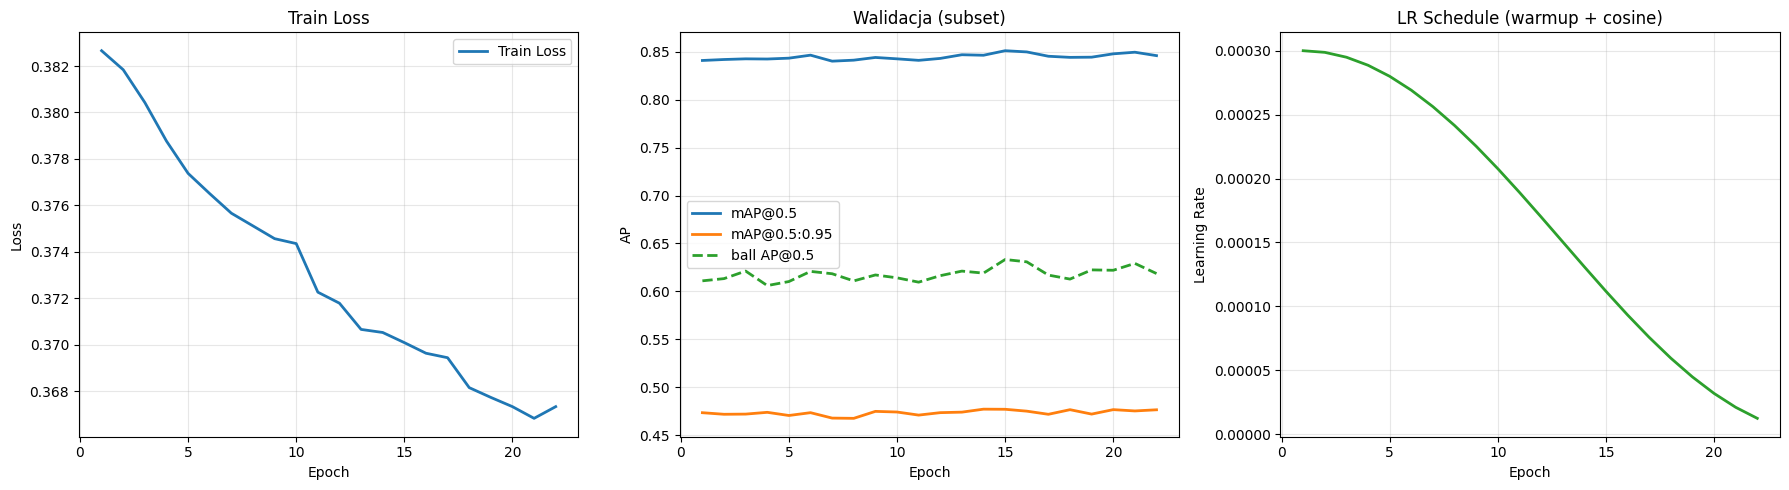

Wykres zapisany: /content/drive/MyDrive/CvFootballTracker_Data/results/frcnn_soccernet_v4/loss_plot.png


In [8]:
import matplotlib.pyplot as plt

if history:
    ep    = [h["epoch"] for h in history]
    tr    = [h["train_loss"] for h in history]
    m50   = [h["map50"] for h in history]
    m5095 = [h["map5095"] for h in history]
    ball  = [h["ball_ap50"] for h in history]
    lrs   = [h["lr"] for h in history]

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    ax1.plot(ep, tr, label="Train Loss", linewidth=2)
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.set_title("Train Loss"); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(ep, m50, label="mAP@0.5", linewidth=2)
    ax2.plot(ep, m5095, label="mAP@0.5:0.95", linewidth=2)
    ax2.plot(ep, ball, label="ball AP@0.5", linewidth=2, linestyle="--")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("AP")
    ax2.set_title("Walidacja (subset)"); ax2.legend(); ax2.grid(True, alpha=0.3)

    ax3.plot(ep, lrs, linewidth=2, color="tab:green")
    ax3.set_xlabel("Epoch"); ax3.set_ylabel("Learning Rate")
    ax3.set_title("LR Schedule (warmup + cosine)"); ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{save_dir}/loss_plot.png", dpi=150)
    plt.show()
    print(f"Wykres zapisany: {save_dir}/loss_plot.png")
else:
    print("Brak danych do wykresu (trening nie uruchomiony w tej sesji)")

## 8. Ewaluacja (mAP) na zbiorze walidacyjnym

COCO-style mAP: AP@0.5 i AP@0.5:0.95 per klasa.

In [10]:
from torchvision.ops import box_iou

# Zaladuj best model
eval_model = create_model(NUM_CLASSES)
ckpt = torch.load(best_path, map_location=device, weights_only=False)
eval_model.load_state_dict(ckpt["model_state_dict"])
eval_model.to(device)
eval_model.eval()

print(f"Zaladowano best.pt (epoch {ckpt['epoch']+1}, mAP50-95={ckpt.get('map5095', ckpt.get('best_map', float('nan'))):.4f})")
print("Ewaluacja na zbiorze walidacyjnym...\n")


def compute_ap(recalls, precisions):
    """AP - 101-point interpolation (COCO-style)."""
    mrec = np.concatenate(([0.0], recalls, [1.0]))
    mpre = np.concatenate(([1.0], precisions, [0.0]))
    for i in range(len(mpre) - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])
    recall_points = np.linspace(0, 1, 101)
    precision_at_recall = np.zeros(101)
    for i, r in enumerate(recall_points):
        idx = np.where(mrec >= r)[0]
        if len(idx) > 0:
            precision_at_recall[i] = mpre[idx[0]]
    return precision_at_recall.mean()


def evaluate_class(all_preds, all_gts, class_id, iou_threshold=0.5):
    """AP dla jednej klasy przy danym IoU threshold."""
    preds = []
    n_gt = 0
    gt_matched = {}

    for img_idx, (pred, gt) in enumerate(zip(all_preds, all_gts)):
        gt_mask = gt["labels"].cpu().numpy() == class_id
        gt_boxes = gt["boxes"].cpu().numpy()[gt_mask]
        n_gt += len(gt_boxes)
        gt_matched[img_idx] = np.zeros(len(gt_boxes), dtype=bool)

        pred_mask = pred["labels"].cpu().numpy() == class_id
        pred_boxes = pred["boxes"].cpu().numpy()[pred_mask]
        pred_scores = pred["scores"].cpu().numpy()[pred_mask]

        for j in range(len(pred_boxes)):
            preds.append((img_idx, pred_scores[j], pred_boxes[j]))

    if n_gt == 0:
        return 0.0

    preds.sort(key=lambda x: x[1], reverse=True)
    tp = np.zeros(len(preds))
    fp = np.zeros(len(preds))

    for i, (img_idx, score, pred_box) in enumerate(preds):
        gt = all_gts[img_idx]
        gt_mask = gt["labels"].cpu().numpy() == class_id
        gt_boxes = gt["boxes"].cpu().numpy()[gt_mask]

        if len(gt_boxes) == 0:
            fp[i] = 1
            continue

        ious = box_iou(
            torch.from_numpy(pred_box).unsqueeze(0).float(),
            torch.from_numpy(gt_boxes).float()
        ).numpy()[0]

        best_iou_idx = ious.argmax()
        best_iou = ious[best_iou_idx]

        if best_iou >= iou_threshold and not gt_matched[img_idx][best_iou_idx]:
            tp[i] = 1
            gt_matched[img_idx][best_iou_idx] = True
        else:
            fp[i] = 1

    cum_tp = np.cumsum(tp)
    cum_fp = np.cumsum(fp)
    recalls = cum_tp / n_gt
    precisions = cum_tp / (cum_tp + cum_fp)

    return compute_ap(recalls, precisions)


# Zbieranie predykcji
all_preds = []
all_gts = []

with torch.no_grad():
    for batch_idx, (images, targets) in enumerate(valid_loader):
        images = [img.to(device) for img in images]
        with torch.amp.autocast(device_type="cuda", enabled=USE_AMP):
            preds = eval_model(images)
        all_preds.extend([{k: v.cpu() for k, v in p.items()} for p in preds])
        all_gts.extend(targets)
        if (batch_idx + 1) % 50 == 0:
            print(f"  {batch_idx+1}/{len(valid_loader)}")

# Raport
print(f"\n{'='*60}")
print(f"Ewaluacja najlepszego modelu (best.pt)")
print(f"{'='*60}")

iou_thresholds_50_95 = np.arange(0.5, 1.0, 0.05)
class_names_eval = {1: 'ball', 2: 'player', 3: 'referee'}

maps_50 = []
maps_50_95 = []

for cls_id, cls_name in class_names_eval.items():
    ap50 = evaluate_class(all_preds, all_gts, cls_id, iou_threshold=0.5)
    aps = [evaluate_class(all_preds, all_gts, cls_id, iou_threshold=t) for t in iou_thresholds_50_95]
    ap50_95 = np.mean(aps)

    maps_50.append(ap50)
    maps_50_95.append(ap50_95)

    print(f"  {cls_name:10s}  AP@0.5: {ap50:.4f}  |  AP@0.5:0.95: {ap50_95:.4f}")

print(f"\n  {'mAP':10s}  AP@0.5: {np.mean(maps_50):.4f}  |  AP@0.5:0.95: {np.mean(maps_50_95):.4f}")
print(f"\nSciezka do modelu: {best_path}")

Zaladowano best.pt (epoch 14, mAP50-95=0.4770)
Ewaluacja na zbiorze walidacyjnym...

  50/1032
  100/1032
  150/1032
  200/1032
  250/1032
  300/1032
  350/1032
  400/1032
  450/1032
  500/1032
  550/1032
  600/1032
  650/1032
  700/1032
  750/1032
  800/1032
  850/1032
  900/1032
  950/1032
  1000/1032

Ewaluacja najlepszego modelu (best.pt)
  ball        AP@0.5: 0.6384  |  AP@0.5:0.95: 0.2625
  player      AP@0.5: 0.9608  |  AP@0.5:0.95: 0.6081
  referee     AP@0.5: 0.9532  |  AP@0.5:0.95: 0.5675

  mAP         AP@0.5: 0.8508  |  AP@0.5:0.95: 0.4794

Sciezka do modelu: /content/drive/MyDrive/CvFootballTracker_Data/results/frcnn_soccernet_v4/best.pt


## 9. Eksport wag do pipeline

Eksportuje sam state_dict (bez optimizer/scheduler) - kompatybilny z `FasterRCNNDetector`.

In [12]:
export_path = f"{save_dir}/trained_fasterrcnn_resnet50.pt"

ckpt = torch.load(best_path, map_location="cpu", weights_only=False)
torch.save(ckpt["model_state_dict"], export_path)

size_mb = os.path.getsize(export_path) / 1e6
print(f"Wyeksportowano: {export_path} ({size_mb:.1f} MB)")
print(f"\nSkopiuj do projektu jako:")
print(f"  models/faster_rcnn/trained_fasterrcnn_resnet50.pt")

Wyeksportowano: /content/drive/MyDrive/CvFootballTracker_Data/results/frcnn_soccernet_v4/trained_fasterrcnn_resnet50.pt (173.4 MB)

Skopiuj do projektu jako:
  models/faster_rcnn/trained_fasterrcnn_resnet50.pt


---
## Komorka opcjonalna - sprzatanie

In [ ]:
target = f"{PROJECT_DIR}/{RUN_NAME}"
if os.path.exists(target):
    confirm = input(f"Usunac {target}? (tak/nie): ")
    if confirm.lower() == "tak":
        shutil.rmtree(target)
        print("Usunieto.")
    else:
        print("Anulowano.")
else:
    print("Folder nie istnieje, nic do usuniecia.")